# Логистическая регрессия: теория и практика

Логистическая регрессия — базовый алгоритм **бинарной классификации**:
несмотря на название "регрессия", она предсказывает не число, а вероятность
принадлежности к классу. Этот ноутбук — теоретический разбор на
синтетических данных, специально сгенерированных так, чтобы показать каждый
эффект изолированно.

**Прикладной разбор на реальных данных** (Titanic) — в
[`notebooks/01_titanic_eda.ipynb`](../notebooks/01_titanic_eda.ipynb) и
[`scripts/train_titanic.py`](../scripts/train_titanic.py). **Общая теория
линейных моделей** (МНК, градиентный спуск, регуляризация, диагностика) — в
[`tutorials/linearregression.ipynb`](../tutorials/linearregression.ipynb),
который стоит прочитать первым — логистическая регрессия унаследует оттуда
и градиентный спуск, и идею регуляризации.

**Содержание:**
1. От регрессии к классификации
2. Сигмоида и логит
3. Разделяющая граница (decision boundary)
4. Функция потерь: log loss и максимальное правдоподобие
5. Обучение: градиентный спуск с нуля и солверы sklearn
6. Регуляризация
7. Метрики классификации и подбор порога
8. Многоклассовая классификация
9. Предположения и ограничения
10. Резюме

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, auc,
)

from utils.plotting import set_style, CATEGORICAL_PALETTE, plot_confusion_matrix, plot_roc_curve

set_style()
rng = np.random.default_rng(42)

## 1. От регрессии к классификации

Почему нельзя просто взять линейную регрессию и предсказывать ей 0/1?
Попробуем в лоб:

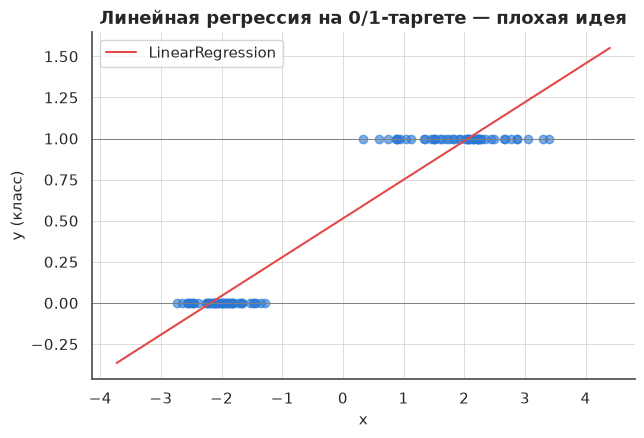

In [2]:
X_demo, y_demo = make_classification(
    n_samples=100, n_features=1, n_informative=1, n_redundant=0,
    n_clusters_per_class=1, class_sep=2.0, random_state=7,
)
x_demo = X_demo[:, 0]

from sklearn.linear_model import LinearRegression
lin_model = LinearRegression().fit(x_demo.reshape(-1, 1), y_demo)
x_grid = np.linspace(x_demo.min() - 1, x_demo.max() + 1, 200)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(x_demo, y_demo, alpha=0.6, color=CATEGORICAL_PALETTE[0])
ax.plot(x_grid, lin_model.predict(x_grid.reshape(-1, 1)), color=CATEGORICAL_PALETTE[3],
        label="LinearRegression")
ax.axhline(0, color="gray", linewidth=0.7); ax.axhline(1, color="gray", linewidth=0.7)
ax.set_xlabel("x"); ax.set_ylabel("y (класс)")
ax.legend(); ax.set_title("Линейная регрессия на 0/1-таргете — плохая идея")
plt.show()

Две проблемы сразу видны на графике:

1. Прямая уходит за пределы $[0, 1]$ — предсказание $\hat{y}=1.3$ или
   $\hat{y}=-0.2$ невозможно интерпретировать как вероятность.
2. Прямая линейно продолжает расти/падать за пределами облака точек — один
   очень "уверенный" выброс далеко справа или слева перекосит всю границу
   классов (в отличие от здоровой S-образной кривой, которая просто
   выходит на плато у 0 и 1).

Нужна функция, которая сжимает любое вещественное число в диапазон
$(0, 1)$, — это и есть сигмоида.

## 2. Сигмоида и логит

$$\sigma(z) = \frac{1}{1+e^{-z}}, \qquad z = w_0 + w_1x_1 + \dots + w_kx_k = Xw$$

Модель логистической регрессии: $\hat{p} = \sigma(Xw)$ — та же линейная
комбинация признаков, что и в линейной регрессии, только "пропущенная"
через сигмоиду, чтобы результат читался как вероятность.

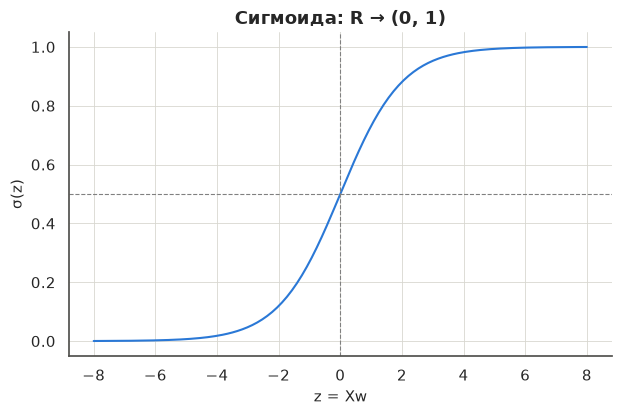

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_grid = np.linspace(-8, 8, 200)
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(z_grid, sigmoid(z_grid), color=CATEGORICAL_PALETTE[0])
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("z = Xw"); ax.set_ylabel("σ(z)")
ax.set_title("Сигмоида: R → (0, 1)")
plt.show()

Обратная функция к сигмоиде — **логит** (log-odds):

$$z = \ln\frac{p}{1-p} = \text{logit}(p)$$

То есть логистическая регрессия линейна не в вероятности, а в **логарифме
отношения шансов** ($\text{odds}=p/(1-p)$). Отсюда и стандартная
интерпретация коэффициентов: увеличение $x_j$ на единицу прибавляет
$w_j$ к логарифму шансов, то есть умножает сами шансы на $e^{w_j}$.

## 3. Разделяющая граница (decision boundary)

На 2D-данных легко увидеть, что именно строит логистическая регрессия:
не кривую, разделяющую классы произвольно, а **прямую линию** (гиперплоскость
в общем случае) — там, где $\hat p = 0.5$, то есть $z = Xw = 0$.

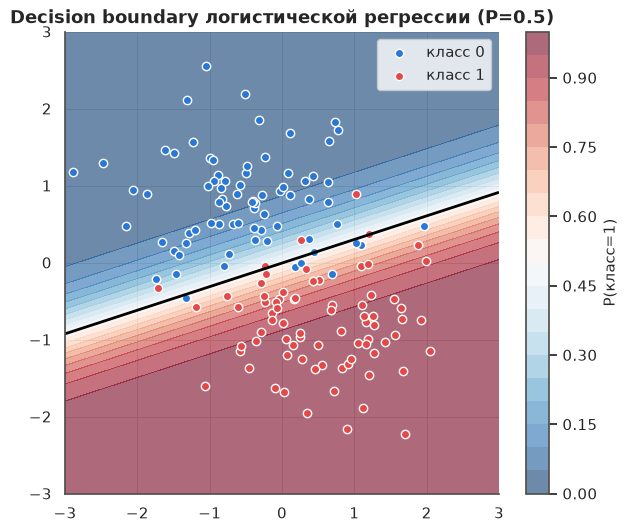

In [4]:
X_blob, y_blob = make_blobs(n_samples=150, centers=2, cluster_std=1.6, random_state=12)
scaler_blob = StandardScaler().fit(X_blob)
X_blob_scaled = scaler_blob.transform(X_blob)

clf = LogisticRegression().fit(X_blob_scaled, y_blob)

xx, yy = np.meshgrid(np.linspace(-3, 3, 300), np.linspace(-3, 3, 300))
grid_prob = clf.predict_proba(np.column_stack([xx.ravel(), yy.ravel()]))[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 6))
contour = ax.contourf(xx, yy, grid_prob, levels=20, cmap="RdBu_r", alpha=0.6)
ax.contour(xx, yy, grid_prob, levels=[0.5], colors="black", linewidths=2)
ax.scatter(*X_blob_scaled[y_blob == 0].T, color=CATEGORICAL_PALETTE[0], edgecolor="white", label="класс 0")
ax.scatter(*X_blob_scaled[y_blob == 1].T, color=CATEGORICAL_PALETTE[3], edgecolor="white", label="класс 1")
fig.colorbar(contour, ax=ax, label="P(класс=1)")
ax.legend(); ax.set_title("Decision boundary логистической регрессии (P=0.5)")
plt.show()

Чёрная линия — граница решения $P=0.5$: она прямая, потому что
$z=Xw=0$ — это уравнение прямой (гиперплоскости) в пространстве признаков.
Это ключевое ограничение логистической регрессии: она умеет отделять только
**линейно разделимые** (или почти линейно разделимые) классы — как ансамбль
метода, добавление полиномиальных признаков (см. `tutorials/linearregression.ipynb`,
раздел 8) может сделать границу нелинейной, ровно как и в регрессии.

## 4. Функция потерь: log loss

Почему для классификации не используют MSE? Если подставить $\hat p = \sigma(Xw)$
в MSE, функция потерь теряет выпуклость — градиентный спуск может застрять
в локальном минимуме. Вместо этого используют **log loss**
(бинарную кросс-энтропию), которую можно вывести из принципа максимального
правдоподобия.

Пусть $y_i \in \{0, 1\}$ — метка, $\hat p_i$ — предсказанная вероятность
класса 1. Правдоподобие одного наблюдения — это вероятность,
которую модель "поставила" на реально наблюдавшийся класс:

$$P(y_i \mid x_i) = \hat p_i^{\,y_i}(1-\hat p_i)^{\,1-y_i}$$

(при $y_i=1$ остаётся $\hat p_i$, при $y_i=0$ остаётся $1-\hat p_i$ — удобная
запись "выключателем" сразу для обоих случаев). Правдоподобие всей выборки —
произведение по всем наблюдениям (считаем их независимыми). Максимизировать
произведение неудобно (числа быстро исчезают), поэтому берут логарифм и
меняют знак, чтобы свести к привычной задаче минимизации:

$$\mathcal{L}(w) = -\frac{1}{n}\sum_{i=1}^n \Big[y_i \ln \hat p_i + (1-y_i)\ln(1-\hat p_i)\Big]$$

Это и есть **log loss**. В отличие от MSE на сигмоиде, log loss остаётся
выпуклой функцией от $w$ — градиентный спуск гарантированно найдёт глобальный
минимум. Посмотрим на форму штрафа для одного наблюдения:

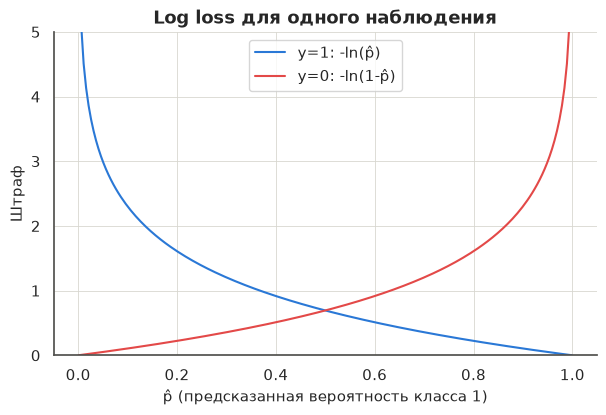

In [5]:
p_grid = np.linspace(0.001, 0.999, 200)
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(p_grid, -np.log(p_grid), color=CATEGORICAL_PALETTE[0], label="y=1: -ln(p̂)")
ax.plot(p_grid, -np.log(1 - p_grid), color=CATEGORICAL_PALETTE[3], label="y=0: -ln(1-p̂)")
ax.set_xlabel("p̂ (предсказанная вероятность класса 1)"); ax.set_ylabel("Штраф")
ax.legend(); ax.set_title("Log loss для одного наблюдения")
ax.set_ylim(0, 5)
plt.show()

Если истинный класс 1, а модель уверенно (близко к 0) предсказала
вероятность класса 1 — штраф улетает к бесконечности: log loss очень жёстко
наказывает **уверенные и неправильные** предсказания, в отличие от
осторожных ошибок около 0.5.

Градиент log loss по весам (вывод опущен, аналогичен выводу градиента MSE в
`tutorials/linearregression.ipynb`, раздел 5) оказывается на удивление
похож на градиент линейной регрессии:

$$\nabla_w \mathcal{L}(w) = \frac{1}{n}X^T(\hat p - y), \qquad \hat p = \sigma(Xw)$$

Единственное отличие от градиента MSE в линейной регрессии — под $\hat p$
стоит $\sigma(Xw)$ вместо $Xw$. Это позволяет использовать тот же самый
градиентный спуск, что и для линейной регрессии.

## 5. Обучение: градиентный спуск с нуля vs sklearn

Реализуем логистическую регрессию тем же способом, что линейную — через
градиентный спуск, — и сравним с `sklearn.LogisticRegression`.

In [6]:
class LogisticRegressionGD:
    def __init__(self, lr=0.5, n_iter=2000):
        self.lr, self.n_iter = lr, n_iter

    def fit(self, X, y):
        X_design = np.column_stack([np.ones(len(X)), X])
        w = np.zeros(X_design.shape[1])
        for _ in range(self.n_iter):
            p_hat = sigmoid(X_design @ w)
            grad = (1 / len(X)) * X_design.T @ (p_hat - y)
            w = w - self.lr * grad
        self.intercept_, self.coef_ = w[0], w[1:]
        return self

    def predict_proba(self, X):
        return sigmoid(self.intercept_ + X @ self.coef_)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


own_clf = LogisticRegressionGD().fit(X_blob_scaled, y_blob)
sk_clf = LogisticRegression(C=np.inf).fit(X_blob_scaled, y_blob)  # C=inf = без регуляризации, для честного сравнения

print(f"С нуля:  w={own_clf.coef_.round(3)}, b={own_clf.intercept_:.3f}")
print(f"sklearn: w={sk_clf.coef_[0].round(3)}, b={sk_clf.intercept_[0]:.3f}")
print(f"Accuracy с нуля: {(own_clf.predict(X_blob_scaled) == y_blob).mean():.4f}")
print(f"Accuracy sklearn: {sk_clf.score(X_blob_scaled, y_blob):.4f}")

С нуля:  w=[ 1.519 -6.033], b=-0.099
sklearn: w=[ 1.523 -6.067], b=-0.098
Accuracy с нуля: 0.9333
Accuracy sklearn: 0.9333


Веса и accuracy практически совпадают — разница объясняется тем, что
`sklearn` использует более точные численные оптимизаторы (см. ниже), а не
"наивный" градиентный спуск с фиксированным `lr`.

### Солверы sklearn

`LogisticRegression` в sklearn поддерживает несколько алгоритмов оптимизации
log loss — все они находят один и тот же глобальный минимум (функция
выпуклая), но с разной скоростью и разными требованиями к данным:

In [7]:
solvers = ["lbfgs", "liblinear", "saga"]
for solver in solvers:
    model = LogisticRegression(solver=solver, max_iter=2000, random_state=0)
    model.fit(X_blob_scaled, y_blob)
    print(f"{solver:>10}: accuracy={model.score(X_blob_scaled, y_blob):.4f}, "
          f"coef={model.coef_[0].round(3)}")

     lbfgs: accuracy=0.9200, coef=[ 1.033 -3.373]
 liblinear: accuracy=0.9200, coef=[ 1.033 -3.373]
      saga: accuracy=0.9200, coef=[ 1.033 -3.374]


- **`lbfgs`** — квазиньютоновский метод (использует приближение вторых
  производных), быстрый и надёжный дефолт для средних датасетов.
- **`liblinear`** — эффективен на небольших датасетах и разреженных
  признаках, единственный, поддерживающий чистую L1-регуляризацию в старых
  версиях sklearn через покоординатный спуск.
- **`saga`** — вариант стохастического градиентного спуска, единственный
  из трёх, который масштабируется на очень большие датасеты и поддерживает
  ElasticNet-регуляризацию.

## 6. Регуляризация в логистической регрессии

Как и в линейной регрессии (`tutorials/linearregression.ipynb`, раздел 10),
к log loss можно добавить L1/L2-штраф за большие веса. В sklearn сила
регуляризации задаётся параметром `C` — это **обратная** величина, то есть
`C` тем меньше, чем **сильнее** регуляризация (`C = 1/λ`).

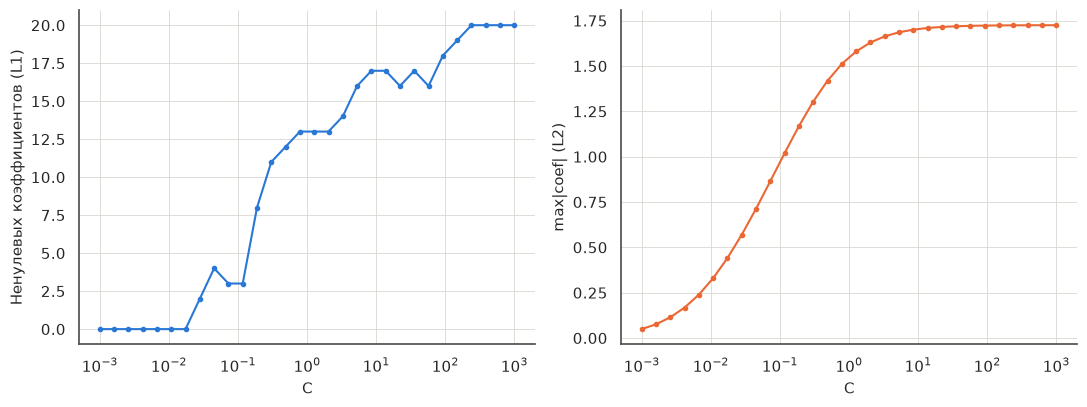

In [8]:
X_wide, y_wide = make_classification(
    n_samples=200, n_features=20, n_informative=4, n_redundant=4,
    random_state=1,
)
X_wide_scaled = StandardScaler().fit_transform(X_wide)

C_grid = np.logspace(-3, 3, 30)
n_nonzero_l1 = []
max_abs_coef_l2 = []
for C in C_grid:
    l1 = LogisticRegression(l1_ratio=1, solver="liblinear", C=C).fit(X_wide_scaled, y_wide)
    l2 = LogisticRegression(l1_ratio=0, C=C).fit(X_wide_scaled, y_wide)
    n_nonzero_l1.append(np.sum(np.abs(l1.coef_[0]) > 1e-4))
    max_abs_coef_l2.append(np.abs(l2.coef_[0]).max())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(C_grid, n_nonzero_l1, "-o", ms=3, color=CATEGORICAL_PALETTE[0])
axes[0].set_xscale("log"); axes[0].set_xlabel("C"); axes[0].set_ylabel("Ненулевых коэффициентов (L1)")
axes[1].plot(C_grid, max_abs_coef_l2, "-o", ms=3, color=CATEGORICAL_PALETTE[1])
axes[1].set_xscale("log"); axes[1].set_xlabel("C"); axes[1].set_ylabel("max|coef| (L2)")
fig.tight_layout()
plt.show()

При маленьком `C` (сильная регуляризация) L1 обнуляет почти все веса — как
и в Lasso для линейной регрессии (тот же геометрический эффект ромбовидной
области допустимых $w$). L2 не обнуляет веса, но сжимает их по модулю: чем
меньше `C`, тем меньше максимальный вес. Слишком маленький `C` — недообучение
(модель слишком ограничена); слишком большой `C` — модель приближается к
нерегуляризованной и рискует переобучиться, особенно на небольших выборках
с большим числом признаков (см. bias-variance tradeoff в
`tutorials/linearregression.ipynb`, раздел 9).

## 7. Метрики классификации

Обучим модель на данных с намеренно **несбалансированными классами**
(90%/10%) — на таких данных accuracy особенно обманчива.

In [9]:
X_imb, y_imb = make_classification(
    n_samples=1000, n_features=6, n_informative=4,
    weights=[0.9, 0.1], random_state=3,
)
X_tr, X_te, y_tr, y_te = train_test_split(X_imb, y_imb, test_size=0.3, stratify=y_imb, random_state=3)
scaler = StandardScaler().fit(X_tr)
clf_imb = LogisticRegression().fit(scaler.transform(X_tr), y_tr)

y_pred = clf_imb.predict(scaler.transform(X_te))
y_prob = clf_imb.predict_proba(scaler.transform(X_te))[:, 1]

print(f"Доля класса 1 в тесте: {y_te.mean():.1%}")
print(f"Accuracy константной модели 'всегда 0': {1 - y_te.mean():.4f}")
print(f"Accuracy обученной модели:              {accuracy_score(y_te, y_pred):.4f}")
print(f"Precision: {precision_score(y_te, y_pred):.4f}  Recall: {recall_score(y_te, y_pred):.4f}  "
      f"F1: {f1_score(y_te, y_pred):.4f}")

Доля класса 1 в тесте: 10.3%
Accuracy константной модели 'всегда 0': 0.8967
Accuracy обученной модели:              0.9067
Precision: 0.5484  Recall: 0.5484  F1: 0.5484


Accuracy обученной модели лишь немного лучше константной "всегда 0" — на
несбалансированных данных этого мало, чтобы судить о качестве. Нужны
**precision** (доля верных среди предсказанных положительными:
$\frac{TP}{TP+FP}$) и **recall** (доля найденных среди всех реально
положительных: $\frac{TP}{TP+FN}$) — они компромиссны: увеличивая порог
классификации, обычно повышаем precision ценой recall, и наоборот.

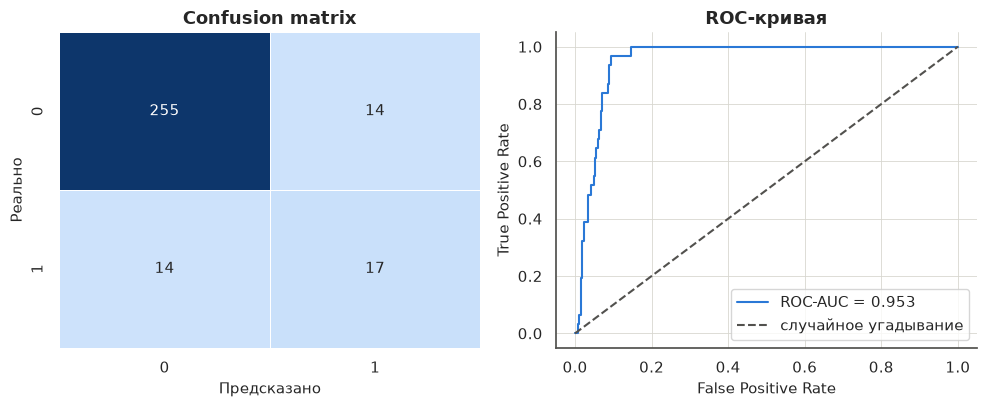

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
plot_confusion_matrix(y_te, y_pred, labels=("0", "1"), ax=axes[0])
plot_roc_curve(y_te, y_prob, ax=axes[1])
fig.tight_layout()
plt.show()

**ROC-AUC** — вероятность того, что случайно выбранный положительный объект
получит более высокую предсказанную вероятность, чем случайно выбранный
отрицательный. В отличие от accuracy, не зависит от порога классификации и
устойчив к дисбалансу классов — поэтому именно ROC-AUC (или PR-AUC при
сильном дисбалансе) обычно используют при сравнении моделей и подборе
гиперпараметров через кросс-валидацию (как в `scripts/train_titanic.py`).

### Подбор порога классификации

По умолчанию порог классификации — 0.5, но это не всегда оптимальный выбор:
если ошибки FP и FN "стоят" по-разному (например, в медицинской диагностике
пропустить болезнь обычно хуже, чем перестраховаться), порог стоит сдвинуть.

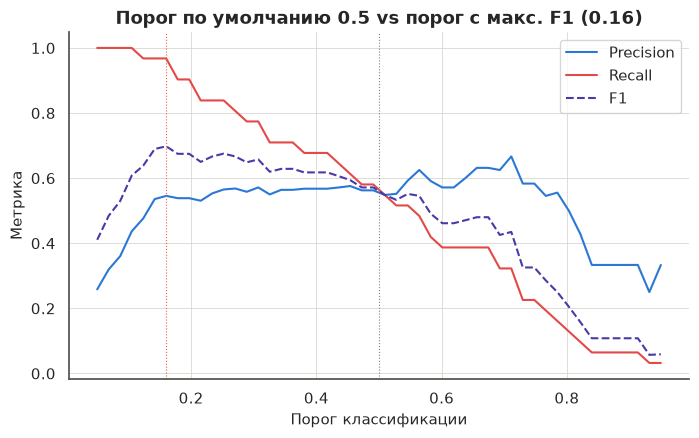

In [11]:
thresholds = np.linspace(0.05, 0.95, 50)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    precisions.append(precision_score(y_te, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_te, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_te, y_pred_t, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thresholds, precisions, color=CATEGORICAL_PALETTE[0], label="Precision")
ax.plot(thresholds, recalls, color=CATEGORICAL_PALETTE[3], label="Recall")
ax.plot(thresholds, f1s, color=CATEGORICAL_PALETTE[4], label="F1", linestyle="--")
ax.axvline(0.5, color="gray", linewidth=0.8, linestyle=":")
best_t = thresholds[np.argmax(f1s)]
ax.axvline(best_t, color=CATEGORICAL_PALETTE[1], linewidth=0.8, linestyle=":")
ax.set_xlabel("Порог классификации"); ax.set_ylabel("Метрика")
ax.legend(); ax.set_title(f"Порог по умолчанию 0.5 vs порог с макс. F1 ({best_t:.2f})")
plt.show()

Precision растёт вместе с порогом (модель осторожнее назначает класс 1 —
среди тех немногих, кому назначила, ошибается реже), recall — падает
(пропускает всё больше настоящих положительных). Порог, максимизирующий F1
(гармоническое среднее precision и recall), не обязан совпадать со
"стандартным" 0.5 — особенно на несбалансированных данных, как здесь.

## 8. Многоклассовая классификация

Логистическая регрессия обобщается на $>2$ классов двумя способами:

- **One-vs-Rest (OvR)** — обучается $K$ независимых бинарных классификаторов
  "класс $k$ против всех остальных", предсказывается класс с наибольшей
  $\hat p_k$.
- **Multinomial (softmax)** — один классификатор сразу на все классы, вместо
  сигмоиды использует softmax: $\hat p_k = \dfrac{e^{z_k}}{\sum_j e^{z_j}}$ —
  честная многоклассовая вероятность, сумма по классам равна 1.

`sklearn.LogisticRegression` с `solver='lbfgs'` по умолчанию использует
multinomial-схему для многоклассовых задач.

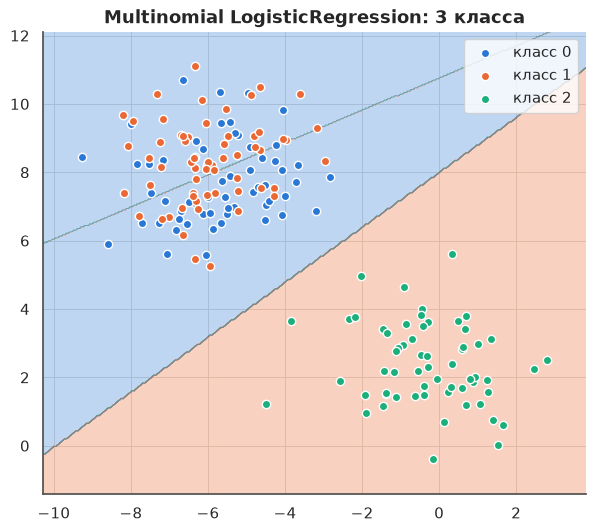

In [12]:
X_multi, y_multi = make_blobs(n_samples=180, centers=3, cluster_std=1.3, random_state=5)
clf_multi = LogisticRegression().fit(X_multi, y_multi)

xx, yy = np.meshgrid(np.linspace(X_multi[:, 0].min() - 1, X_multi[:, 0].max() + 1, 300),
                      np.linspace(X_multi[:, 1].min() - 1, X_multi[:, 1].max() + 1, 300))
zz = clf_multi.predict(np.column_stack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(xx, yy, zz, alpha=0.3, colors=CATEGORICAL_PALETTE[:3])
for k, color in enumerate(CATEGORICAL_PALETTE[:3]):
    ax.scatter(*X_multi[y_multi == k].T, color=color, edgecolor="white", label=f"класс {k}")
ax.legend(); ax.set_title("Multinomial LogisticRegression: 3 класса")
plt.show()

Каждая пара классов по-прежнему разделена прямой линией — граница между
любыми двумя соседними областями линейна, просто теперь таких границ
несколько.

## 9. Предположения и ограничения

- **Линейная разделимость (в пространстве признаков).** Граница решения —
  всегда гиперплоскость; сильно нелинейные закономерности требуют
  полиномиальных/взаимодействующих признаков или другой модели.
- **Независимость наблюдений** и **отсутствие сильной мультиколлинеарности**
  — те же требования, что у линейной регрессии (раздел 4 и 11 в
  `tutorials/linearregression.ipynb`): коррелированные признаки делают
  коэффициенты неустойчивыми.
- **Чувствительность к масштабу признаков** — как и для градиентного спуска
  в линейной регрессии, признаки стоит стандартизировать (особенно важно
  при использовании регуляризации: без стандартизации штраф `C` по-разному
  "давит" на признаки с разным исходным масштабом).
- **Дисбаланс классов** — сам по себе не ломает обучение, но требует
  осторожности при выборе метрики (раздел 7) и, возможно, порога
  классификации или весов классов (`class_weight='balanced'`).

## 10. Резюме

- Логистическая регрессия = линейная комбинация признаков, пропущенная
  через сигмоиду, чтобы результат читался как вероятность.
- Обучается минимизацией **log loss** — выпуклой функции, выводимой из
  принципа максимального правдоподобия; градиент почти идентичен градиенту
  MSE в линейной регрессии, различие только в $\hat p = \sigma(Xw)$
  вместо $\hat y = Xw$.
- Регуляризация (L1/L2 через параметр `C`) работает так же, как в линейной
  регрессии: L1 обнуляет веса, L2 их сжимает.
- Accuracy — плохая метрика при дисбалансе классов; precision/recall/F1/
  ROC-AUC и подбор порога классификации дают куда более полную картину.
- Граница решения всегда линейна (гиперплоскость) — нелинейные
  зависимости требуют инженерии признаков.

**Прикладной пример** со всеми этими идеями на реальных данных — `Titanic`:
`notebooks/01_titanic_eda.ipynb` (разведочный анализ) и
`scripts/train_titanic.py` (полный пайплайн обучения с honest
baseline-vs-final сравнением).